# Analysis of Experimental Results for L* Algorithm Variants on Tree Automata

## Experiments Description

The goal of the experiments is to compare different variants of the L* algorithm for learning deterministic finite tree automata (DFTA).

### Algorithm variants:

1. **Standard L\*** - The classical L* algorithm for learning tree automata (baseline).
2. **L\* with advice** - L* augmented with advice provided by a term-rewriting system.
3. **Approximate L\*** - An approximate variant that replaces equivalence queries with numerous membership queries with random trees.
4. **Approximate L\* with advice** - A combination of the advice-guided approach and the approximate (membership-only) strategy.
5. **Approximate L\* with advice and using random testing in checking consistency with TRS** - A variant of 4. that additionally checks consistency on a random sample (random testing) instead of looking through the entire domain.
6. **Approximate L\* with advice and using counting heuristic in checking consistency with TRS** - A variant of 4. that applies a counting-based heuristic in the consistency checking step before searching for counterexamples in the entire domain.

### Experiments - Rewriting Rules:

- **Associativity** - Tree automata constructed from DFAs over words. Advice (encoding associativity): **f(T1, f(T2, T3)) = f(f(T1, T2), T3)**
- **Distributivity** - Automata over symbols with arities f/2, g/1 and 0-ary symbols (constants). Advice: **g(f(T1, T2)) = f(g(T1), g(T2))**

For each rewriting rule, a tree automaton is generated. Then all presented variants of L* are run to learn the generated automaton. Results are saved as a record in the results table (there are two tables, one for Associativity and one for Distributivity).

Each record contains information about the analyzed automaton and learning results from each variant of the algorithm.

In the section about the analyzed automaton, the following information is provided:

- **Number of leaf symbols** - Number of distinct leaf symbols in the alphabet.
- **States in word automata** - (only in Associativity) Tree automata are based on random word automata (see TODO). This is the number of states in the word automaton.
- **States in tree automata** - Number of states in the generated tree automaton.

For variants **1.** and **2.**, the following information is recorded:

- **Equivalence queries count** - Number of equivalence queries asked during the learning process.
- **Time** - Time consumed to learn the automaton.

For variants **3.**, **4.**, **5.**, and **6.**, the following information is recorded:

- **Time** - Time consumed to learn the automaton.
- **Consumed Tokens** - In these variants, the equivalence query is approximated by numerous membership queries. Each membership query consumes as many tokens as there are vertices in the queried tree (total number of vertices across all trees queried via membership queries during learning).
- **Is automata found** - Since the equivalence query is only approximated, the algorithm may return an incorrect automaton. This indicates whether the correct automaton was found.


## Table of Contents

- [1. Associativity Analysis](#1.-Associativity-Analysis)
    - [1.1 Comparison of equivalence queries: Standard vs. Advice](#1.1-Comparison-of-the-number-of-asked-equivalence-queries:-Standard-vs.-Advice)
    - [1.2 Comparison of approximation methods](#1.2-Comparison-of-approximation-methods---Associativity)
    - [1.3 Profitability analysis](#1.3-Profitability-analysis---Associativity)
    - [1.4 Per-automaton break-even token cost](#1.4-Per-automaton-break-even-token-cost---Associativity)
- [2. Distributivity Analysis](#2.-Distributivity-Analysis)
    - [2.1 Comparison of equivalence queries: Standard vs Advice](#2.1-Comparison-of-equivalence-queries:-Standard-vs-Advice)
    - [2.2 Comparison of approximation methods](#2.2-Comparison-of-approximation-methods---Distributivity)
    - [2.3 Profitability analysis](#2.3-Profitability-analysis---Distributivity)
    - [2.4 Per-automaton break-even token cost](#2.4-Per-automaton-break-even-token-cost---Distributivity)
- [3. Comparative Summary](#3.-Comparative-Summary)
    - [3.1 Comparison of both experiments](#3.1-Comparison-of-both-experiments)
    - [3.2 Key Results Summary](#3.2-Key-Results-Summary)
    - [3.3 Conclusions](#3.3-Conclusions)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11


## Reading Data

In [2]:
# reading data
conn_df = pd.read_csv('connectivity_merged_results.csv')
dist_df = pd.read_csv('distributivity_merged_results.csv')

print(f"Associativity: {len(conn_df)} rows")
print(f"Distributivity: {len(dist_df)} rows")
print()
print("Associativity - columns:")
print(conn_df.columns.tolist())
print()
print("Distributivity - columns:")
print(dist_df.columns.tolist())


Associativity: 935 rows
Distributivity: 655 rows

Associativity - columns:
['Number of leaf symbols', 'States in word automata', 'States in tree automata', 'Standard equivalence queries', 'Standard time', 'Advice equivalence queries', 'Advice time', 'Approximate time', 'Approximate tokens', 'Approximate is_found', 'Approximate advice time', 'Approximate advice tokens', 'Approximate advice is_found', 'Approximate random check time', 'Approximate random check tokens', 'Approximate random check is_found', 'Approximate counting heuristic time', 'Approximate counting heuristic tokens', 'Approximate counting heuristic is_found']

Distributivity - columns:
['Number of leaf symbols', 'States in tree automata', 'Standard equivalence queries', 'Standard time', 'Advice equivalence queries', 'Advice time', 'Approximate time', 'Approximate tokens', 'Approximate is_found', 'Approximate advice time', 'Approximate advice tokens', 'Approximate advice is_found', 'Approximate random check time', 'Approxi

## Basic Stats

In [3]:
# Basic stats
print("=== Associativity ===")
print(conn_df.describe())
print()
print("=== Distributivity ===")
print(dist_df.describe())


=== Associativity ===
       Number of leaf symbols  States in word automata  \
count              935.000000               935.000000   
mean                 2.840642                 4.557219   
std                  0.816883                 1.265879   
min                  2.000000                 3.000000   
25%                  2.000000                 4.000000   
50%                  3.000000                 4.000000   
75%                  4.000000                 5.000000   
max                  4.000000                10.000000   

       States in tree automata  Standard equivalence queries  Standard time  \
count               935.000000                    935.000000     935.000000   
mean                 66.441711                     12.332620       2.671658   
std                  48.211021                      6.318251       6.907790   
min                  20.000000                      1.000000       0.000000   
25%                  27.000000                      7.000000

---
# 1. Associativity Analysis


## 1.1 Comparison of the number of asked equivalence queries: Standard vs. Advice

Here you can see how many equivalence queries you can **save**.


In [4]:
# Only valid experiments - remove extreme values using IQR method
conn_valid = conn_df.copy()

# Remove trivial cases (too few eq queries to be meaningful)
MIN_EQ_QUERIES = 3
conn_valid = conn_valid[conn_valid['Standard equivalence queries'] >= MIN_EQ_QUERIES]

# Remove outliers based on Standard equivalence queries (IQR method)
Q1 = conn_valid['Standard equivalence queries'].quantile(0.25)
Q3 = conn_valid['Standard equivalence queries'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Before filtering: {len(conn_df)} rows")
print(f"Removed trivial cases (Standard eq. queries < {MIN_EQ_QUERIES}): {len(conn_df) - len(conn_valid)} rows")
print(f"IQR bounds for Standard eq. queries: [{lower_bound:.1f}, {upper_bound:.1f}]")

conn_valid = conn_valid[
    (conn_valid['Standard equivalence queries'] >= lower_bound) &
    (conn_valid['Standard equivalence queries'] <= upper_bound)
]

print(f"After filtering: {len(conn_valid)} rows (removed {len(conn_df) - len(conn_valid)} total)")

print(f"\nExperiments count: {len(conn_valid)}")
print(f"\nEquivalence query statistics:")
print(f"  Standard - mean: {conn_valid['Standard equivalence queries'].mean():.2f}, median: {conn_valid['Standard equivalence queries'].median():.1f}")
print(f"  Advice   - mean: {conn_valid['Advice equivalence queries'].mean():.2f}, median: {conn_valid['Advice equivalence queries'].median():.1f}")
print(f"\n  Profit (mean): {(1 - conn_valid['Advice equivalence queries'].mean() / conn_valid['Standard equivalence queries'].mean()) * 100:.1f}%")
print(f"  Profit (median): {(1 - conn_valid['Advice equivalence queries'].median() / conn_valid['Standard equivalence queries'].median()) * 100:.1f}%")


Before filtering: 935 rows
Removed trivial cases (Standard eq. queries < 3): 45 rows
IQR bounds for Standard eq. queries: [0.0, 24.0]
After filtering: 841 rows (removed 94 total)

Experiments count: 841

Equivalence query statistics:
  Standard - mean: 12.00, median: 12.0
  Advice   - mean: 2.58, median: 2.0

  Profit (mean): 78.5%
  Profit (median): 83.3%


### Result
**78.5%** of equivalence queries can be saved if we have information that the symbol in the automaton is associative


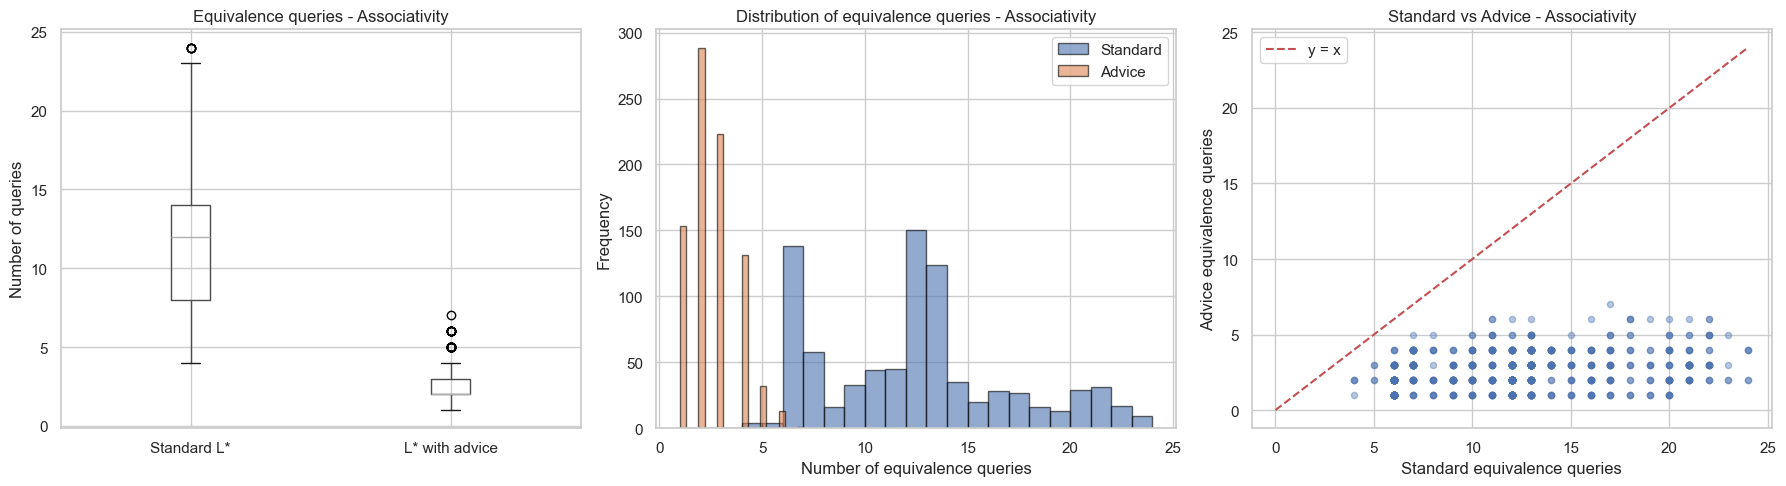

In [5]:
# Equivalence queries comparison chart - Associativity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot
data_eq = pd.DataFrame({
    'Standard L*': conn_valid['Standard equivalence queries'],
    'L* with advice': conn_valid['Advice equivalence queries']
})
data_eq.boxplot(ax=axes[0])
axes[0].set_title('Equivalence queries - Associativity')
axes[0].set_ylabel('Number of queries')

# Histogram
axes[1].hist(conn_valid['Standard equivalence queries'], alpha=0.6, label='Standard', bins=20, edgecolor='black')
axes[1].hist(conn_valid['Advice equivalence queries'], alpha=0.6, label='Advice', bins=20, edgecolor='black')
axes[1].set_xlabel('Number of equivalence queries')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of equivalence queries - Associativity')
axes[1].legend()

# Scatter: Standard vs Advice
axes[2].scatter(conn_valid['Standard equivalence queries'], conn_valid['Advice equivalence queries'], alpha=0.4, s=20)
max_val = max(conn_valid['Standard equivalence queries'].max(), conn_valid['Advice equivalence queries'].max())
axes[2].plot([0, max_val], [0, max_val], 'r--', label='y = x')
axes[2].set_xlabel('Standard equivalence queries')
axes[2].set_ylabel('Advice equivalence queries')
axes[2].set_title('Standard vs Advice - Associativity')
axes[2].legend()

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **Left (Box plot):** Compares the distributions of equivalence queries for Standard L* and L* with advice. The box shows the interquartile range (IQR), the line inside is the median, and whiskers extend to 1.5×IQR. Outliers are shown as individual points.
- **Middle (Histogram):** Shows the frequency distribution of equivalence query counts for both methods overlaid. This reveals how the values are spread and where the bulk of experiments fall for each method.
- **Right (Scatter):** Each point represents one experiment, with Standard eq. queries on the x-axis and Advice eq. queries on the y-axis. Points below the red y=x line indicate experiments where advice reduced the number of equivalence queries.


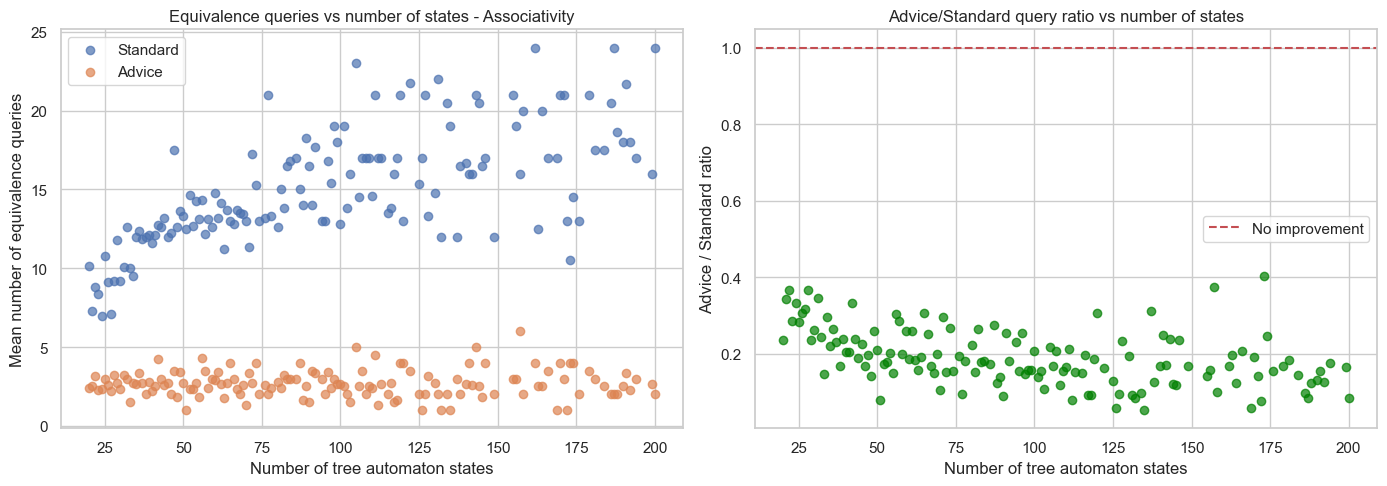

In [6]:
# Equivalence queries vs number of tree automaton states
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Group by number of states
conn_grouped = conn_valid.groupby('States in tree automata').agg({
    'Standard equivalence queries': 'mean',
    'Advice equivalence queries': 'mean'
}).reset_index()

axes[0].scatter(conn_grouped['States in tree automata'], conn_grouped['Standard equivalence queries'], label='Standard', alpha=0.7)
axes[0].scatter(conn_grouped['States in tree automata'], conn_grouped['Advice equivalence queries'], label='Advice', alpha=0.7)
axes[0].set_xlabel('Number of tree automaton states')
axes[0].set_ylabel('Mean number of equivalence queries')
axes[0].set_title('Equivalence queries vs number of states - Associativity')
axes[0].legend()

# Advice/Standard ratio
conn_valid_ratio = conn_valid[conn_valid['Standard equivalence queries'] > 0].copy()
conn_valid_ratio['ratio'] = conn_valid_ratio['Advice equivalence queries'] / conn_valid_ratio['Standard equivalence queries']
ratio_grouped = conn_valid_ratio.groupby('States in tree automata')['ratio'].mean().reset_index()

axes[1].scatter(ratio_grouped['States in tree automata'], ratio_grouped['ratio'], alpha=0.7, color='green')
axes[1].axhline(y=1, color='r', linestyle='--', label='No improvement')
axes[1].set_xlabel('Number of tree automaton states')
axes[1].set_ylabel('Advice / Standard ratio')
axes[1].set_title('Advice/Standard query ratio vs number of states')
axes[1].legend()

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **Left (Scatter - mean eq. queries vs states):** Shows how the mean number of equivalence queries grows with the number of tree automaton states, for both Standard and Advice methods. This reveals the scaling behavior of each approach as automaton complexity increases.
- **Right (Advice/Standard ratio vs states):** Shows the ratio of Advice equivalence queries to Standard equivalence queries as a function of automaton size. Values below 1.0 (red dashed line) indicate that the Advice method requires fewer equivalence queries. Lower ratios mean greater benefit from using advice.


In [7]:
# Statistical test - Wilcoxon signed-rank test
stat, p_value = stats.wilcoxon(
    conn_valid['Standard equivalence queries'],
    conn_valid['Advice equivalence queries']
)
print(f"Wilcoxon signed-rank test (Associativity):")
print(f"  Statistic: {stat:.2f}")
print(f"  p-value: {p_value:.2e}")
print(f"  {'Statistically significant difference (p < 0.05)' if p_value < 0.05 else 'No significant difference'}")


Wilcoxon signed-rank test (Associativity):
  Statistic: 0.00
  p-value: 1.31e-139
  Statistically significant difference (p < 0.05)


**Interpretation:**

The Wilcoxon signed-rank test is a non-parametric statistical test used to determine whether two paired samples come from the same distribution. Here it compares the number of equivalence queries required by the Standard L* algorithm versus L* with advice on the same set of automata.

- **Statistic** – the test statistic value (sum of ranks of positive differences). A value close to 0 indicates that almost all paired differences go in one direction.
- **p-value** – the probability of observing such a result under the null hypothesis (no difference). A very small p-value (p < 0.05) means the difference is statistically significant.

In this case the extremely low p-value confirms that the reduction in equivalence queries achieved by the advice-guided variant is not due to chance – the improvement is statistically significant across the tested automata.


## 1.2 Comparison of approximation methods - Associativity

We compare the number of tokens (membership queries) and time for different approximation variants.
Key question: how much should one token cost for a given approximation method to be more profitable than a standard equivalence query?


In [8]:
# Token comparison between approximation variants - Associativity
# Filter only experiments where the automaton was found
conn_approx = conn_valid[conn_valid['Approximate is_found'] == 1].copy()
conn_approx_adv = conn_valid[conn_valid['Approximate advice is_found'] == 1].copy()
conn_approx_rand = conn_valid[conn_valid['Approximate random check is_found'] == 1].copy()
conn_approx_count = conn_valid[conn_valid['Approximate counting heuristic is_found'] == 1].copy()

print("=== Associativity - Comparison of approximation methods ===")
print(f"\nNumber of successful experiments:")
print(f"  Approximate:                 {len(conn_approx)} / {len(conn_valid)} ({100*len(conn_approx)/len(conn_valid):.1f}%)")
print(f"  Approximate advice:          {len(conn_approx_adv)} / {len(conn_valid)} ({100*len(conn_approx_adv)/len(conn_valid):.1f}%)")
print(f"  Approximate random check:    {len(conn_approx_rand)} / {len(conn_valid)} ({100*len(conn_approx_rand)/len(conn_valid):.1f}%)")
print(f"  Approximate counting heur.:  {len(conn_approx_count)} / {len(conn_valid)} ({100*len(conn_approx_count)/len(conn_valid):.1f}%)")

print(f"\nMean number of tokens (successful only):")
print(f"  Approximate:                 {conn_approx['Approximate tokens'].mean():.0f}")
print(f"  Approximate advice:          {conn_approx_adv['Approximate advice tokens'].mean():.0f}")
print(f"  Approximate random check:    {conn_approx_rand['Approximate random check tokens'].mean():.0f}")
print(f"  Approximate counting heur.:  {conn_approx_count['Approximate counting heuristic tokens'].mean():.0f}")

print(f"\nMean time [s] (successful only):")
print(f"  Approximate:                 {conn_approx['Approximate time'].mean():.2f}")
print(f"  Approximate advice:          {conn_approx_adv['Approximate advice time'].mean():.2f}")
print(f"  Approximate random check:    {conn_approx_rand['Approximate random check time'].mean():.2f}")
print(f"  Approximate counting heur.:  {conn_approx_count['Approximate counting heuristic time'].mean():.2f}")


=== Associativity - Comparison of approximation methods ===

Number of successful experiments:
  Approximate:                 768 / 841 (91.3%)
  Approximate advice:          813 / 841 (96.7%)
  Approximate random check:    802 / 841 (95.4%)
  Approximate counting heur.:  812 / 841 (96.6%)

Mean number of tokens (successful only):
  Approximate:                 4634787
  Approximate advice:          6873965
  Approximate random check:    9973603
  Approximate counting heur.:  6534882

Mean time [s] (successful only):
  Approximate:                 6.22
  Approximate advice:          8.18
  Approximate random check:    43.18
  Approximate counting heur.:  7.55


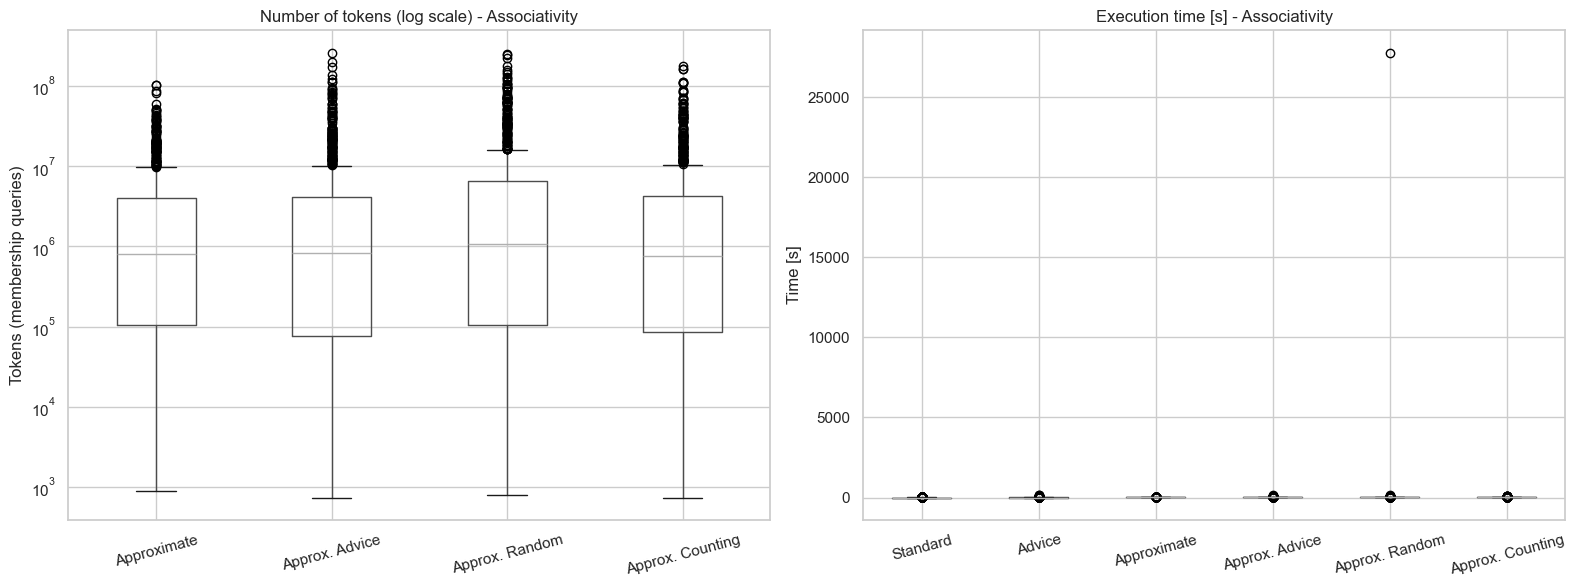

In [9]:
# Token and time charts - Associativity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tokens - box plot (log scale)
token_data = pd.DataFrame({
    'Approximate': conn_approx['Approximate tokens'],
    'Approx. Advice': conn_approx_adv['Approximate advice tokens'],
    'Approx. Random': conn_approx_rand['Approximate random check tokens'],
    'Approx. Counting': conn_approx_count['Approximate counting heuristic tokens']
})
token_data.boxplot(ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Number of tokens (log scale) - Associativity')
axes[0].set_ylabel('Tokens (membership queries)')
axes[0].tick_params(axis='x', rotation=15)

# Time - box plot
time_data = pd.DataFrame({
    'Standard': conn_valid['Standard time'],
    'Advice': conn_valid['Advice time'],
    'Approximate': conn_approx['Approximate time'],
    'Approx. Advice': conn_approx_adv['Approximate advice time'],
    'Approx. Random': conn_approx_rand['Approximate random check time'],
    'Approx. Counting': conn_approx_count['Approximate counting heuristic time']
})
time_data.boxplot(ax=axes[1])
axes[1].set_title('Execution time [s] - Associativity')
axes[1].set_ylabel('Time [s]')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **Left (Tokens - box plot, log scale):** Compares the distribution of consumed tokens (total tree vertices queried via membership queries) across the four approximate methods: Approximate, Approximate with Advice, Approximate with Random Check, and Approximate with Counting Heuristic. The y-axis uses a logarithmic scale due to the wide range of token values. Lower values indicate more efficient methods in terms of membership query cost.
- **Right (Time - box plot):** Compares the execution time distributions for all six L* variants (Standard, Advice, and the four approximate methods). This reveals which methods are faster in practice and how variable their runtimes are.


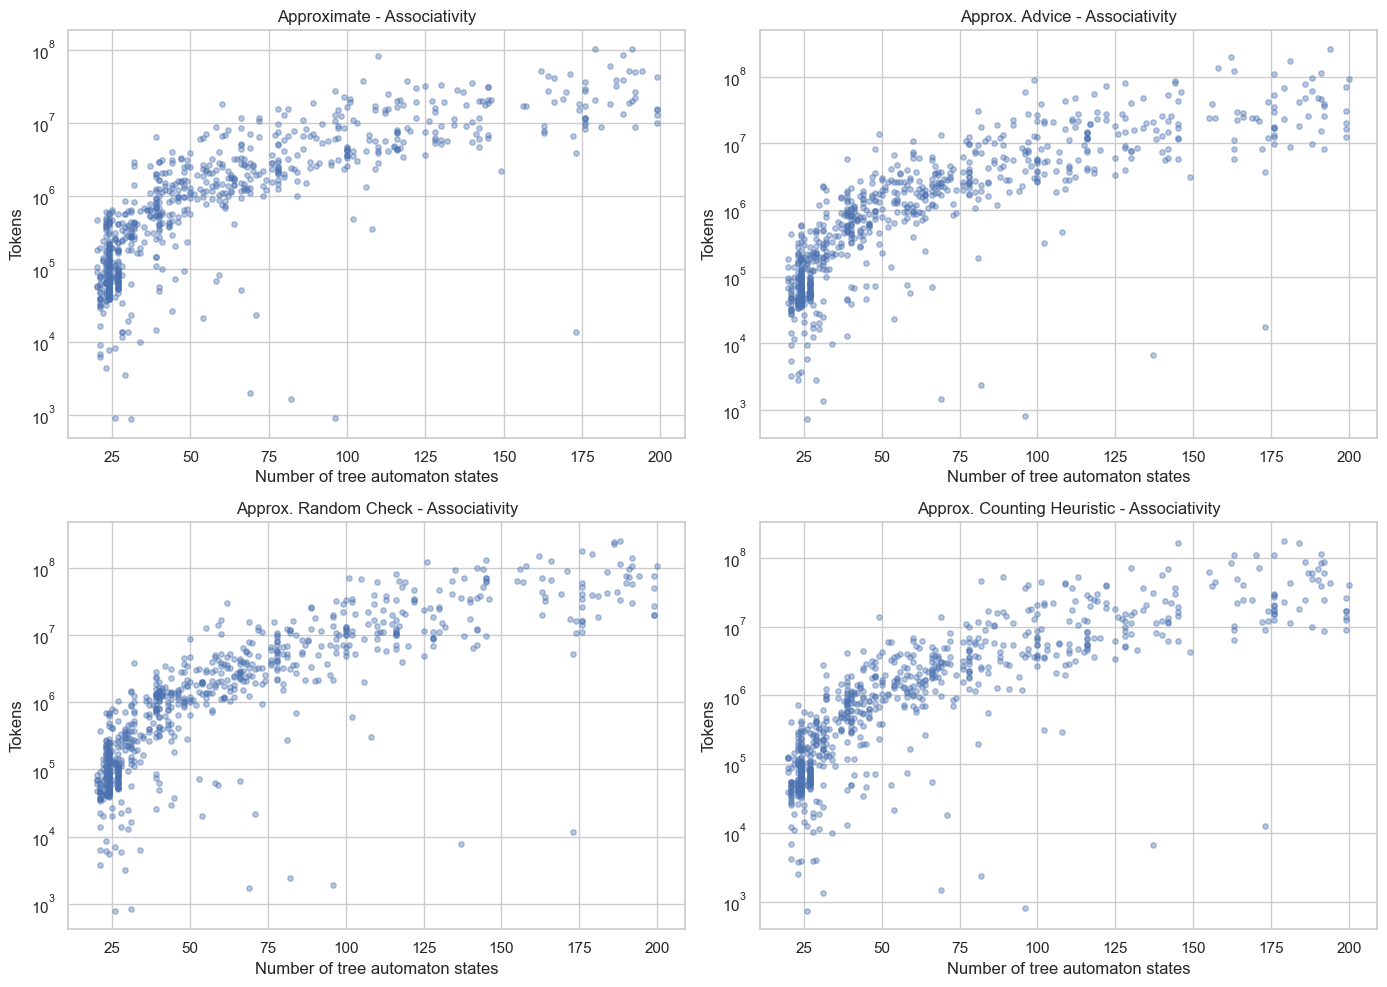

In [10]:
# Tokens vs number of states - Associativity
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = [
    ('Approximate tokens', 'Approximate is_found', 'Approximate'),
    ('Approximate advice tokens', 'Approximate advice is_found', 'Approx. Advice'),
    ('Approximate random check tokens', 'Approximate random check is_found', 'Approx. Random Check'),
    ('Approximate counting heuristic tokens', 'Approximate counting heuristic is_found', 'Approx. Counting Heuristic')
]

for idx, (token_col, found_col, name) in enumerate(methods):
    ax = axes[idx // 2][idx % 2]
    subset = conn_valid[conn_valid[found_col] == 1]
    ax.scatter(subset['States in tree automata'], subset[token_col], alpha=0.4, s=15)
    ax.set_xlabel('Number of tree automaton states')
    ax.set_ylabel('Tokens')
    ax.set_title(f'{name} - Associativity')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **2×2 grid of scatter plots:** Each subplot shows the relationship between the number of tree automaton states (x-axis) and the number of consumed tokens (y-axis, log scale) for one of the four approximate methods. This reveals how token consumption scales with automaton complexity for each method. Points higher on the y-axis indicate experiments that required more tokens. The log scale helps visualize the wide range of token values across different automaton sizes.


## 1.3 Profitability analysis - Associativity

We compare the 4 approximation methods (3-6) in terms of tokens and time.

Key question: given that all approximate methods avoid equivalence queries, how much should 1000 tokens cost for one method to be more profitable than another?

We compare each method against the baseline Approximate (method 3). A method is more profitable when:
- `(tokens_method / 1000) * cost_per_1k + time_method < (tokens_baseline / 1000) * cost_per_1k + time_baseline`

All costs are expressed in milliseconds. The x-axis shows cost per 1000 tokens [ms].


In [11]:
# Profitability analysis - Associativity
# Compare the 4 approximate methods among themselves
# Baseline: Approximate (method 3). Compare against: Approx Advice (4), Approx Random (5), Approx Counting (6)

# Filter: only experiments where ALL approximate methods found the automaton
conn_all_approx = conn_valid[
    (conn_valid['Approximate is_found'] == 1) &
    (conn_valid['Approximate advice is_found'] == 1) &
    (conn_valid['Approximate random check is_found'] == 1) &
    (conn_valid['Approximate counting heuristic is_found'] == 1)
].copy()

print(f"Experiments where all 4 approximate methods succeeded: {len(conn_all_approx)} / {len(conn_valid)}")

# Compare tokens and time
methods_approx = {
    'Approximate': ('Approximate tokens', 'Approximate time'),
    'Approx. Advice': ('Approximate advice tokens', 'Approximate advice time'),
    'Approx. Random': ('Approximate random check tokens', 'Approximate random check time'),
    'Approx. Counting': ('Approximate counting heuristic tokens', 'Approximate counting heuristic time'),
}

print(f"\n{'Method':<20} {'Mean tokens':<15} {'Median tokens':<15} {'Mean time [s]':<15}")
print("-" * 65)
for name, (tok_col, time_col) in methods_approx.items():
    print(f"{name:<20} {conn_all_approx[tok_col].mean():<15.0f} {conn_all_approx[tok_col].median():<15.0f} {conn_all_approx[time_col].mean():<15.2f}")

# For each cost per 1000 tokens, compute total cost = (tokens/1000) * cost_per_1k_ms + time_ms
# Find break-even cost per 1000 tokens where Approx Advice becomes cheaper than Approximate
print("\n--- Break-even cost per 1000 tokens: method becomes cheaper than Approximate (method 3) ---")
print(f"{'Comparison':<35} {'Mean token diff':<18} {'Mean time diff [ms]':<22} {'Mean break-even [ms/1k tokens]':<25}")
print("-" * 100)

baseline_tokens = conn_all_approx['Approximate tokens']
baseline_time = conn_all_approx['Approximate time']

for name, (tok_col, time_col) in methods_approx.items():
    if name == 'Approximate':
        continue
    method_tokens = conn_all_approx[tok_col]
    method_time = conn_all_approx[time_col]
    
    # method is cheaper when: (method_tokens/1000)*tc_ms + method_time_ms < (baseline_tokens/1000)*tc_ms + baseline_time_ms
    # ((method_tokens - baseline_tokens)/1000) * tc_ms < (baseline_time - method_time) * 1000
    token_diff = (method_tokens - baseline_tokens) / 1000
    time_diff_ms = (baseline_time - method_time) * 1000  # convert s to ms
    
    mask = token_diff != 0
    breakeven = time_diff_ms[mask] / token_diff[mask]
    print(f"{name + ' vs Approximate':<35} {token_diff.mean():<18.0f} {time_diff_ms.mean():<22.0f} {breakeven.mean():<25.2e}")


Experiments where all 4 approximate methods succeeded: 705 / 841

Method               Mean tokens     Median tokens   Mean time [s]  
-----------------------------------------------------------------
Approximate          4591292         765885          6.21           
Approx. Advice       5930346         713842          7.69           
Approx. Random       9628244         999314          47.76          
Approx. Counting     5919594         698609          7.19           

--- Break-even cost per 1000 tokens: method becomes cheaper than Approximate (method 3) ---
Comparison                          Mean token diff    Mean time diff [ms]    Mean break-even [ms/1k tokens]
----------------------------------------------------------------------------------------------------
Approx. Advice vs Approximate       1339               -1475                  -9.51e+00                
Approx. Random vs Approximate       5037               -41546                 -2.15e+01                
Approx. Coun

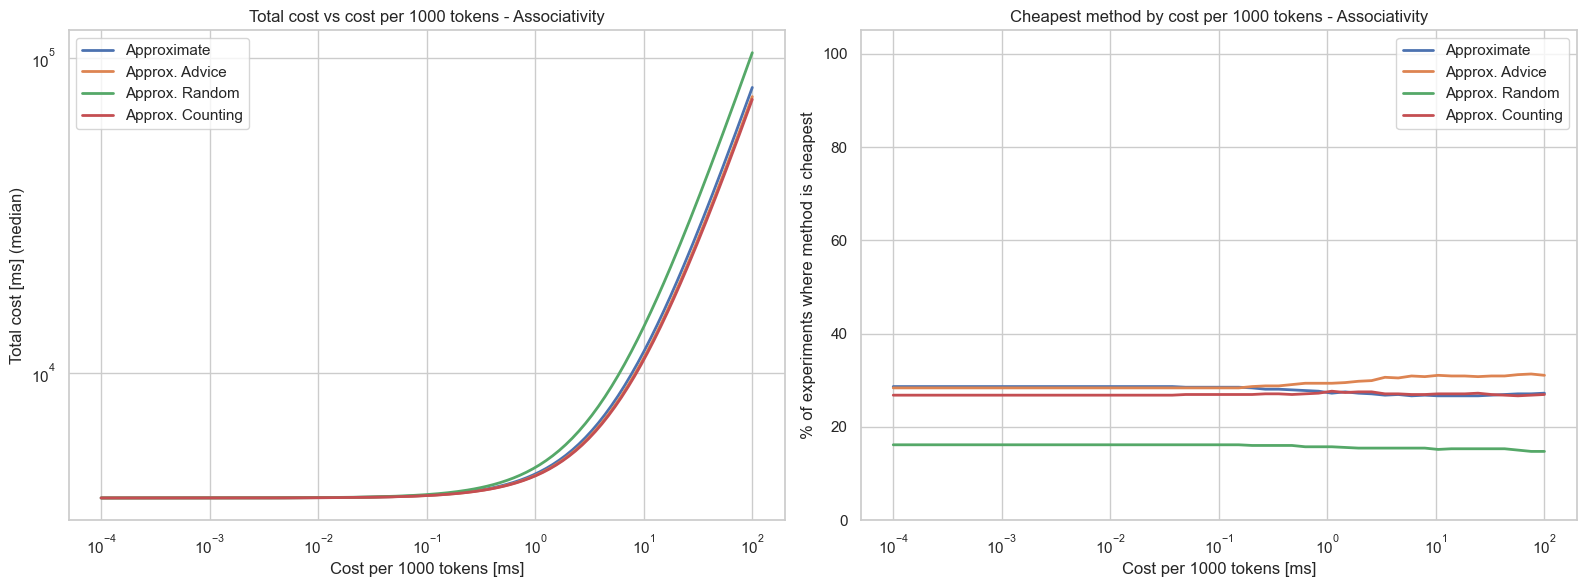

In [12]:
# Break-even chart - Associativity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: total cost vs cost per 1000 tokens for each method
cost_per_1k_range = np.logspace(-4, 2, 200)  # ms per 1000 tokens

for name, (tok_col, time_col) in methods_approx.items():
    median_tokens = conn_all_approx[tok_col].median()
    median_time_ms = conn_all_approx[time_col].median() * 1000  # s -> ms
    total_cost_ms = (median_tokens / 1000) * cost_per_1k_range + median_time_ms
    axes[0].loglog(cost_per_1k_range, total_cost_ms, label=name, linewidth=2)

axes[0].set_xlabel('Cost per 1000 tokens [ms]')
axes[0].set_ylabel('Total cost [ms] (median)')
axes[0].set_title('Total cost vs cost per 1000 tokens - Associativity')
axes[0].legend()
axes[0].grid(True)

# Right plot: % of experiments where each method is the cheapest
cost_per_1k_pct = np.logspace(-4, 2, 50)  # ms per 1000 tokens
pct_cheapest = {name: [] for name in methods_approx.keys()}

for tc in cost_per_1k_pct:
    costs = {}
    for name, (tok_col, time_col) in methods_approx.items():
        costs[name] = (conn_all_approx[tok_col] / 1000) * tc + conn_all_approx[time_col] * 1000
    
    cost_df = pd.DataFrame(costs)
    cheapest = cost_df.idxmin(axis=1)
    for name in methods_approx.keys():
        pct_cheapest[name].append((cheapest == name).mean() * 100)

for name in methods_approx.keys():
    axes[1].semilogx(cost_per_1k_pct, pct_cheapest[name], label=name, linewidth=2)

axes[1].set_xlabel('Cost per 1000 tokens [ms]')
axes[1].set_ylabel('% of experiments where method is cheapest')
axes[1].set_title('Cheapest method by cost per 1000 tokens - Associativity')
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **Left (Total cost vs cost per 1000 tokens):** Shows how the total cost (time + token cost) changes as the price per 1000 tokens varies (x-axis, log scale). Each line represents one approximate method. The crossover points indicate where one method becomes cheaper than another. This helps determine under what pricing conditions each method is most economical.
- **Right (Cheapest method percentage):** For each token cost value (x-axis), shows the percentage of experiments where each method was the cheapest option. This reveals which method dominates at different price points and helps identify the practical break-even regions between methods.


## 1.4 Per-automaton break-even token cost - Associativity

For each pair of methods (3 vs 4, 3 vs 5, 3 vs 6), we compute the break-even cost per 1000 tokens **for each individual automaton** (where both methods succeeded), then aggregate with mean and median.

Break-even for a single automaton: the cost per 1000 tokens at which both methods have equal total cost:
- `(tokens_A / 1000) * c + time_A = (tokens_B / 1000) * c + time_B`
- `c = (time_B - time_A) * 1000 / ((tokens_A - tokens_B) / 1000)` [ms per 1000 tokens]

Positive value means: below this cost, the method with fewer tokens wins.


In [13]:
# Per-automaton break-even token cost - Associativity
# For each comparison (3 vs 4, 3 vs 5, 3 vs 6), compute break-even for each row

comparisons_conn = {
    'Approx. Advice (4) vs Approx. (3)': {
        'baseline': ('Approximate tokens', 'Approximate time', 'Approximate is_found'),
        'method': ('Approximate advice tokens', 'Approximate advice time', 'Approximate advice is_found'),
    },
    'Approx. Random (5) vs Approx. (3)': {
        'baseline': ('Approximate tokens', 'Approximate time', 'Approximate is_found'),
        'method': ('Approximate random check tokens', 'Approximate random check time', 'Approximate random check is_found'),
    },
    'Approx. Counting (6) vs Approx. (3)': {
        'baseline': ('Approximate tokens', 'Approximate time', 'Approximate is_found'),
        'method': ('Approximate counting heuristic tokens', 'Approximate counting heuristic time', 'Approximate counting heuristic is_found'),
    },
}

print("=== Associativity: Per-automaton break-even cost [ms / 1000 tokens] ===")
print(f"{'Comparison':<40} {'Count':<8} {'> 0':<8} {'Mean':<12} {'Median':<12} {'Min':<12} {'Max':<12} {'Std':<12}")
print("-" * 112)

breakeven_data_conn = {}

for comp_name, cols in comparisons_conn.items():
    b_tok, b_time, b_found = cols['baseline']
    m_tok, m_time, m_found = cols['method']
    
    # Filter: both methods found the automaton
    mask = (conn_valid[b_found] == 1) & (conn_valid[m_found] == 1)
    subset = conn_valid[mask].copy()
    
    # Compute per-row break-even: c = (time_method - time_baseline) * 1000 / ((tokens_baseline - tokens_method) / 1000)
    # Method is cheaper when tokens_method < tokens_baseline AND time_method >= time_baseline (or vice versa)
    token_diff = (subset[b_tok] - subset[m_tok]) / 1000  # in thousands
    time_diff_ms = (subset[m_time] - subset[b_time]) * 1000  # ms (positive = method is slower)
    
    # break-even: c = time_diff_ms / token_diff
    # Only meaningful where token_diff != 0
    valid = token_diff != 0
    breakeven_values = time_diff_ms[valid] / token_diff[valid]
    
    breakeven_data_conn[comp_name] = breakeven_values
    
    print(f"{comp_name:<40} {len(breakeven_values):<8} {(breakeven_values > 0).sum():<8} {breakeven_values.mean():<12.4f} {breakeven_values.median():<12.4f} {breakeven_values.min():<12.4f} {breakeven_values.max():<12.4f} {breakeven_values.std():<12.4f}")


=== Associativity: Per-automaton break-even cost [ms / 1000 tokens] ===
Comparison                               Count    > 0      Mean         Median       Min          Max          Std         
----------------------------------------------------------------------------------------------------------------
Approx. Advice (4) vs Approx. (3)        748      69       -9.2070      0.0000       -1642.0361   2194.3574    134.2084    
Approx. Random (5) vs Approx. (3)        744      41       -20.4652     0.0000       -18681.9270  4545.4545    707.4418    
Approx. Counting (6) vs Approx. (3)      744      55       -12.3253     0.0000       -20833.3333  5076.1421    817.0078    


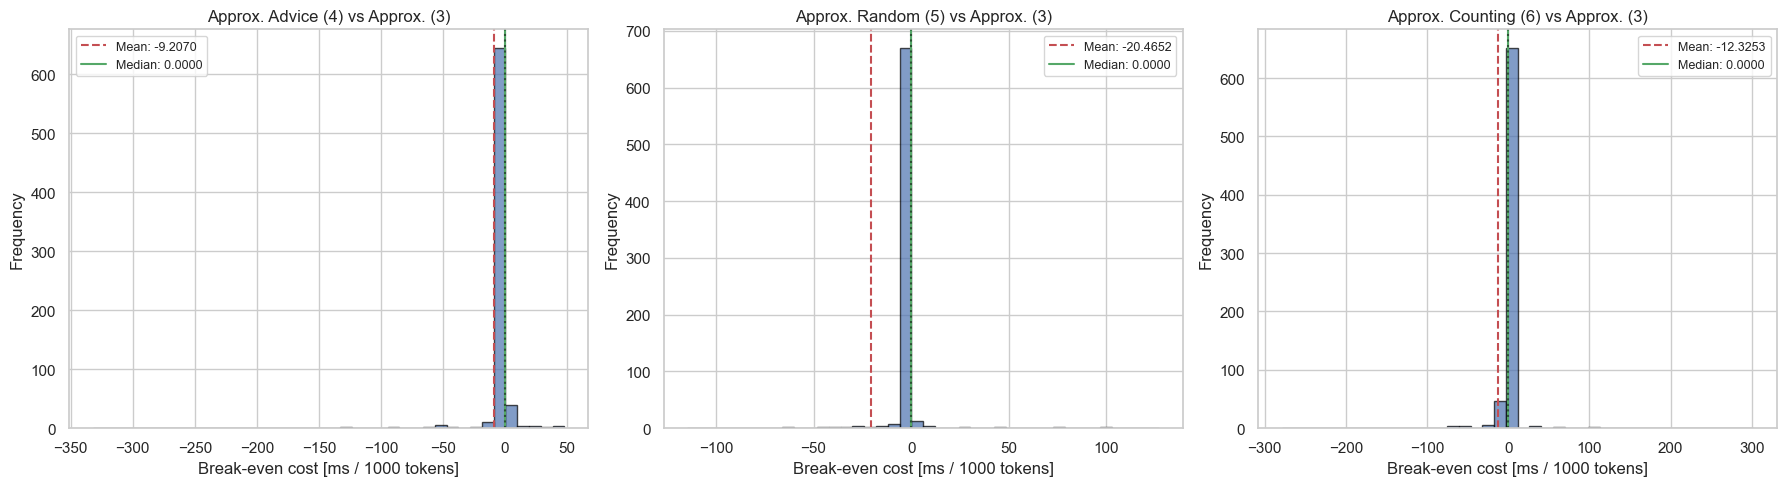

In [14]:
# Distribution of per-automaton break-even values - Associativity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (comp_name, values) in enumerate(breakeven_data_conn.items()):
    ax = axes[idx]
    # Filter out extreme outliers for visualization
    q01 = values.quantile(0.01)
    q99 = values.quantile(0.99)
    filtered = values[(values >= q01) & (values <= q99)]
    
    ax.hist(filtered, bins=40, edgecolor='black', alpha=0.7)
    ax.axvline(x=values.mean(), color='r', linestyle='--', label=f'Mean: {values.mean():.4f}')
    ax.axvline(x=values.median(), color='g', linestyle='-', label=f'Median: {values.median():.4f}')
    ax.axvline(x=0, color='black', linestyle=':', alpha=0.5)
    ax.set_xlabel('Break-even cost [ms / 1000 tokens]')
    ax.set_ylabel('Frequency')
    ax.set_title(comp_name)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **Three histograms:** Each histogram shows the distribution of per-automaton break-even token cost values for one comparison pair (Approximate vs. Approximate with Advice, Approximate vs. Approximate with Random Check, Approximate vs. Approximate with Counting Heuristic). The break-even value is the cost per 1000 tokens at which the compared method becomes cheaper than the baseline Approximate method. A vertical red line marks the median. Values to the left of the median indicate experiments where the alternative method becomes profitable at lower token costs.


---
# 2. Distributivity Analysis


## 2.1 Comparison of equivalence queries: Standard vs Advice


In [15]:
# Filter data - Distributivity (remove extreme values using IQR)
dist_valid = dist_df.copy()

# Remove trivial cases (too few eq queries to be meaningful)
dist_valid = dist_valid[dist_valid['Standard equivalence queries'] >= MIN_EQ_QUERIES]

Q1_d = dist_valid['Standard equivalence queries'].quantile(0.25)
Q3_d = dist_valid['Standard equivalence queries'].quantile(0.75)
IQR_d = Q3_d - Q1_d
lower_d = Q1_d - 1.5 * IQR_d
upper_d = Q3_d + 1.5 * IQR_d

print(f"Before filtering: {len(dist_df)} rows")
print(f"Removed trivial cases (Standard eq. queries < {MIN_EQ_QUERIES})")
print(f"IQR bounds for Standard eq. queries: [{lower_d:.1f}, {upper_d:.1f}]")

dist_valid = dist_valid[
    (dist_valid['Standard equivalence queries'] >= lower_d) &
    (dist_valid['Standard equivalence queries'] <= upper_d)
]

print(f"After filtering: {len(dist_valid)} rows (removed {len(dist_df) - len(dist_valid)} total)")

print(f"Experiments count: {len(dist_valid)}")
print(f"\nEquivalence query statistics:")
print(f"  Standard - mean: {dist_valid['Standard equivalence queries'].mean():.2f}, median: {dist_valid['Standard equivalence queries'].median():.1f}")
print(f"  Advice   - mean: {dist_valid['Advice equivalence queries'].mean():.2f}, median: {dist_valid['Advice equivalence queries'].median():.1f}")
print(f"\n  Reduction (mean): {(1 - dist_valid['Advice equivalence queries'].mean() / dist_valid['Standard equivalence queries'].mean()) * 100:.1f}%")
print(f"  Reduction (median): {(1 - dist_valid['Advice equivalence queries'].median() / dist_valid['Standard equivalence queries'].median()) * 100:.1f}%")


Before filtering: 655 rows
Removed trivial cases (Standard eq. queries < 3)
IQR bounds for Standard eq. queries: [-2.0, 30.0]
After filtering: 567 rows (removed 88 total)
Experiments count: 567

Equivalence query statistics:
  Standard - mean: 13.46, median: 13.0
  Advice   - mean: 4.85, median: 4.0

  Reduction (mean): 64.0%
  Reduction (median): 69.2%


### Result
**64%** of equivalence queries can be saved if we have information that the symbol in the automaton is distributive

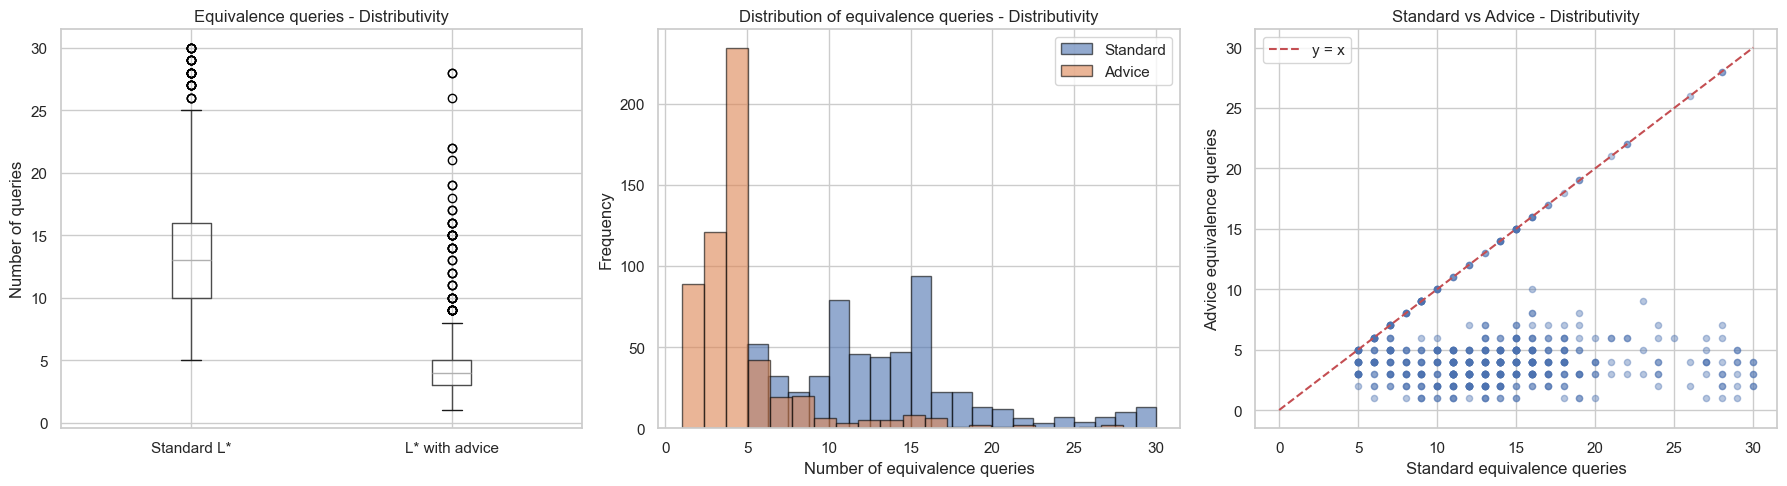

In [16]:

# Equivalence queries comparison chart - Distributivity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box plot
data_eq_dist = pd.DataFrame({
    'Standard L*': dist_valid['Standard equivalence queries'],
    'L* with advice': dist_valid['Advice equivalence queries']
})
data_eq_dist.boxplot(ax=axes[0])
axes[0].set_title('Equivalence queries - Distributivity')
axes[0].set_ylabel('Number of queries')

# Histogram
axes[1].hist(dist_valid['Standard equivalence queries'], alpha=0.6, label='Standard', bins=20, edgecolor='black')
axes[1].hist(dist_valid['Advice equivalence queries'], alpha=0.6, label='Advice', bins=20, edgecolor='black')
axes[1].set_xlabel('Number of equivalence queries')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of equivalence queries - Distributivity')
axes[1].legend()

# Scatter: Standard vs Advice
axes[2].scatter(dist_valid['Standard equivalence queries'], dist_valid['Advice equivalence queries'], alpha=0.4, s=20)
max_val = max(dist_valid['Standard equivalence queries'].max(), dist_valid['Advice equivalence queries'].max())
axes[2].plot([0, max_val], [0, max_val], 'r--', label='y = x')
axes[2].set_xlabel('Standard equivalence queries')
axes[2].set_ylabel('Advice equivalence queries')
axes[2].set_title('Standard vs Advice - Distributivity')
axes[2].legend()

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **Left (Box plot):** Compares the distributions of equivalence queries for Standard L* and L* with advice on the Distributivity property. The box shows the interquartile range (IQR), the line inside is the median, and whiskers extend to 1.5×IQR. Outliers are shown as individual points.
- **Middle (Histogram):** Shows the frequency distribution of equivalence query counts for both methods overlaid. This reveals how the values are spread and where the bulk of experiments fall for each method.
- **Right (Scatter):** Each point represents one experiment, with Standard eq. queries on the x-axis and Advice eq. queries on the y-axis. Points below the red y=x line indicate experiments where advice reduced the number of equivalence queries.


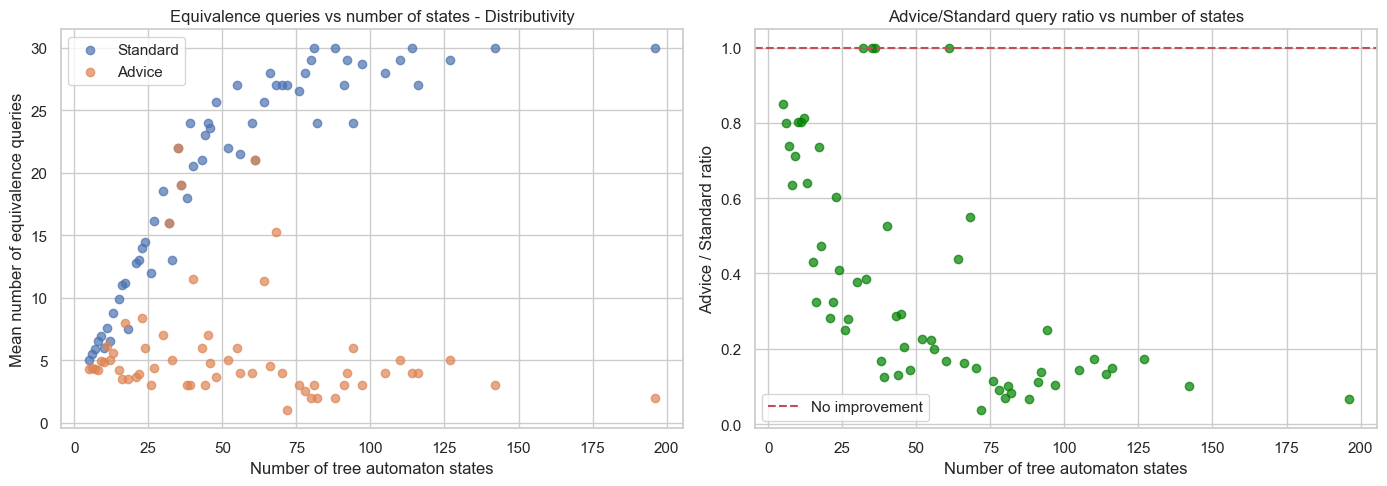

In [17]:
# Equivalence queries vs number of states - Distributivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dist_grouped = dist_valid.groupby('States in tree automata').agg({
    'Standard equivalence queries': 'mean',
    'Advice equivalence queries': 'mean'
}).reset_index()

axes[0].scatter(dist_grouped['States in tree automata'], dist_grouped['Standard equivalence queries'], label='Standard', alpha=0.7)
axes[0].scatter(dist_grouped['States in tree automata'], dist_grouped['Advice equivalence queries'], label='Advice', alpha=0.7)
axes[0].set_xlabel('Number of tree automaton states')
axes[0].set_ylabel('Mean number of equivalence queries')
axes[0].set_title('Equivalence queries vs number of states - Distributivity')
axes[0].legend()

# Advice/Standard ratio
dist_valid_ratio = dist_valid[dist_valid['Standard equivalence queries'] > 0].copy()
dist_valid_ratio['ratio'] = dist_valid_ratio['Advice equivalence queries'] / dist_valid_ratio['Standard equivalence queries']
ratio_grouped_dist = dist_valid_ratio.groupby('States in tree automata')['ratio'].mean().reset_index()

axes[1].scatter(ratio_grouped_dist['States in tree automata'], ratio_grouped_dist['ratio'], alpha=0.7, color='green')
axes[1].axhline(y=1, color='r', linestyle='--', label='No improvement')
axes[1].set_xlabel('Number of tree automaton states')
axes[1].set_ylabel('Advice / Standard ratio')
axes[1].set_title('Advice/Standard query ratio vs number of states')
axes[1].legend()

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **Left (Scatter - mean eq. queries vs states):** Shows how the mean number of equivalence queries grows with the number of tree automaton states for the Distributivity property, for both Standard and Advice methods. This reveals the scaling behavior of each approach as automaton complexity increases.
- **Right (Advice/Standard ratio vs states):** Shows the ratio of Advice equivalence queries to Standard equivalence queries as a function of automaton size. Values below 1.0 (red dashed line) indicate that the Advice method requires fewer equivalence queries. Lower ratios mean greater benefit from using advice.


In [18]:
# Statistical test - Wilcoxon signed-rank test - Distributivity
stat, p_value = stats.wilcoxon(
    dist_valid['Standard equivalence queries'],
    dist_valid['Advice equivalence queries']
)
print(f"Wilcoxon signed-rank test (Distributivity):")
print(f"  Statistic: {stat:.2f}")
print(f"  p-value: {p_value:.2e}")
print(f"  {'Statistically significant difference (p < 0.05)' if p_value < 0.05 else 'No significant difference'}")


Wilcoxon signed-rank test (Distributivity):
  Statistic: 0.00
  p-value: 2.80e-81
  Statistically significant difference (p < 0.05)


**Interpretation:**

Same test as in the Associativity section. The Wilcoxon signed-rank test compares paired equivalence query counts (Standard vs. Advice) for each generated automaton in the Distributivity experiment.

Again, the very low p-value confirms that the advice-guided L* variant requires significantly fewer equivalence queries than the standard variant – the improvement is statistically significant for the distributivity rewriting rule as well.


## 2.2 Comparison of approximation methods - Distributivity

We compare the number of tokens and time for different approximation variants.


In [19]:
# Token comparison between approximation variants - Distributivity
dist_approx = dist_valid[dist_valid['Approximate is_found'] == 1].copy()
dist_approx_adv = dist_valid[dist_valid['Approximate advice is_found'] == 1].copy()
dist_approx_rand = dist_valid[dist_valid['Approximate random check is_found'] == 1].copy()
dist_approx_count = dist_valid[dist_valid['Approximate counting heuristic is_found'] == 1].copy()

print("=== Distributivity - Comparison of approximation methods ===")
print(f"\nNumber of successful experiments:")
print(f"  Approximate:                 {len(dist_approx)} / {len(dist_valid)} ({100*len(dist_approx)/len(dist_valid):.1f}%)")
print(f"  Approximate advice:          {len(dist_approx_adv)} / {len(dist_valid)} ({100*len(dist_approx_adv)/len(dist_valid):.1f}%)")
print(f"  Approximate random check:    {len(dist_approx_rand)} / {len(dist_valid)} ({100*len(dist_approx_rand)/len(dist_valid):.1f}%)")
print(f"  Approximate counting heur.:  {len(dist_approx_count)} / {len(dist_valid)} ({100*len(dist_approx_count)/len(dist_valid):.1f}%)")

print(f"\nMean number of tokens (successful only):")
print(f"  Approximate:                 {dist_approx['Approximate tokens'].mean():.0f}")
print(f"  Approximate advice:          {dist_approx_adv['Approximate advice tokens'].mean():.0f}")
print(f"  Approximate random check:    {dist_approx_rand['Approximate random check tokens'].mean():.0f}")
print(f"  Approximate counting heur.:  {dist_approx_count['Approximate counting heuristic tokens'].mean():.0f}")

print(f"\nMedian number of tokens (successful only):")
print(f"  Approximate:                 {dist_approx['Approximate tokens'].median():.0f}")
print(f"  Approximate advice:          {dist_approx_adv['Approximate advice tokens'].median():.0f}")
print(f"  Approximate random check:    {dist_approx_rand['Approximate random check tokens'].median():.0f}")
print(f"  Approximate counting heur.:  {dist_approx_count['Approximate counting heuristic tokens'].median():.0f}")

print(f"\nMean time [s] (successful only):")
print(f"  Approximate:                 {dist_approx['Approximate time'].mean():.2f}")
print(f"  Approximate advice:          {dist_approx_adv['Approximate advice time'].mean():.2f}")
print(f"  Approximate random check:    {dist_approx_rand['Approximate random check time'].mean():.2f}")
print(f"  Approximate counting heur.:  {dist_approx_count['Approximate counting heuristic time'].mean():.2f}")


=== Distributivity - Comparison of approximation methods ===

Number of successful experiments:
  Approximate:                 512 / 567 (90.3%)
  Approximate advice:          517 / 567 (91.2%)
  Approximate random check:    504 / 567 (88.9%)
  Approximate counting heur.:  515 / 567 (90.8%)

Mean number of tokens (successful only):
  Approximate:                 576698
  Approximate advice:          1016720
  Approximate random check:    967519
  Approximate counting heur.:  894212

Median number of tokens (successful only):
  Approximate:                 104024
  Approximate advice:          120134
  Approximate random check:    125371
  Approximate counting heur.:  119194

Mean time [s] (successful only):
  Approximate:                 4.47
  Approximate advice:          4.53
  Approximate random check:    4.47
  Approximate counting heur.:  4.50


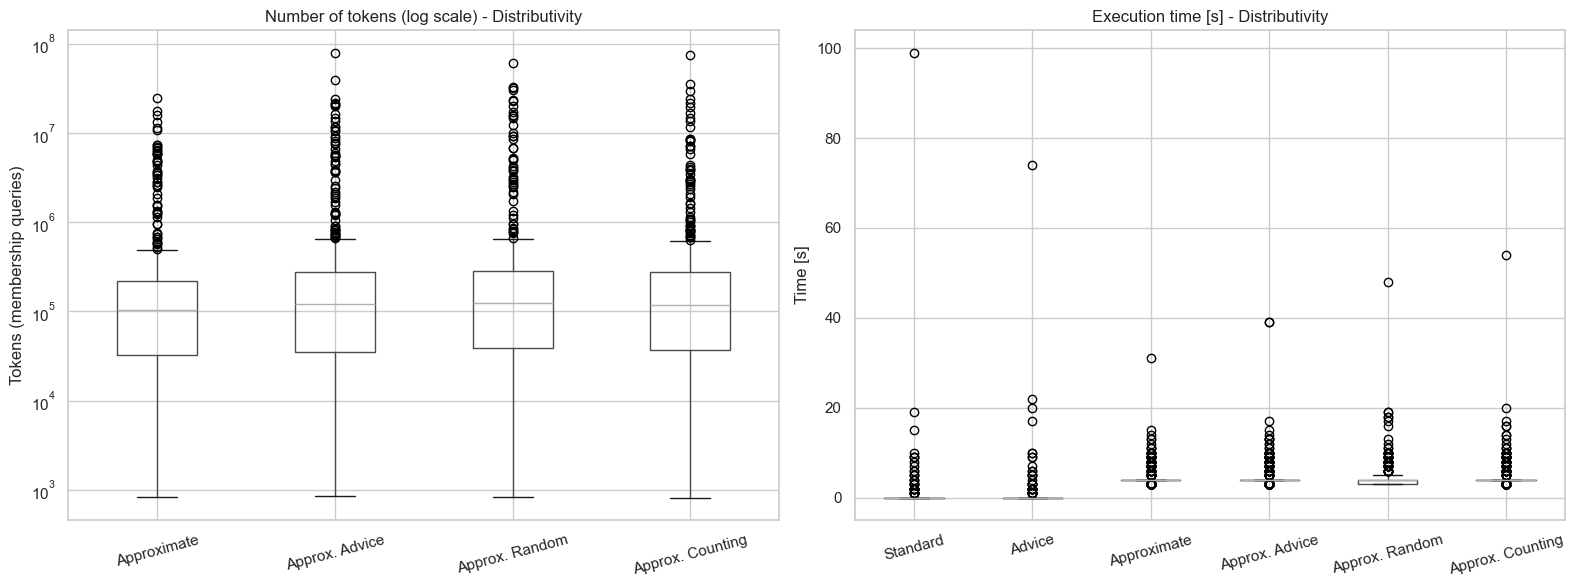

In [20]:
# Token and time charts - Distributivity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tokens - box plot (log scale)
token_data_dist = pd.DataFrame({
    'Approximate': dist_approx['Approximate tokens'],
    'Approx. Advice': dist_approx_adv['Approximate advice tokens'],
    'Approx. Random': dist_approx_rand['Approximate random check tokens'],
    'Approx. Counting': dist_approx_count['Approximate counting heuristic tokens']
})
token_data_dist.boxplot(ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Number of tokens (log scale) - Distributivity')
axes[0].set_ylabel('Tokens (membership queries)')
axes[0].tick_params(axis='x', rotation=15)

# Time - box plot
time_data_dist = pd.DataFrame({
    'Standard': dist_valid['Standard time'],
    'Advice': dist_valid['Advice time'],
    'Approximate': dist_approx['Approximate time'],
    'Approx. Advice': dist_approx_adv['Approximate advice time'],
    'Approx. Random': dist_approx_rand['Approximate random check time'],
    'Approx. Counting': dist_approx_count['Approximate counting heuristic time']
})
time_data_dist.boxplot(ax=axes[1])
axes[1].set_title('Execution time [s] - Distributivity')
axes[1].set_ylabel('Time [s]')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **Left (Tokens - box plot, log scale):** Compares the distribution of consumed tokens across the four approximate methods for the Distributivity property. The y-axis uses a logarithmic scale due to the wide range of token values. Lower values indicate more efficient methods in terms of membership query cost.
- **Right (Time - box plot):** Compares the execution time distributions for all six L* variants on the Distributivity property. This reveals which methods are faster in practice and how variable their runtimes are.


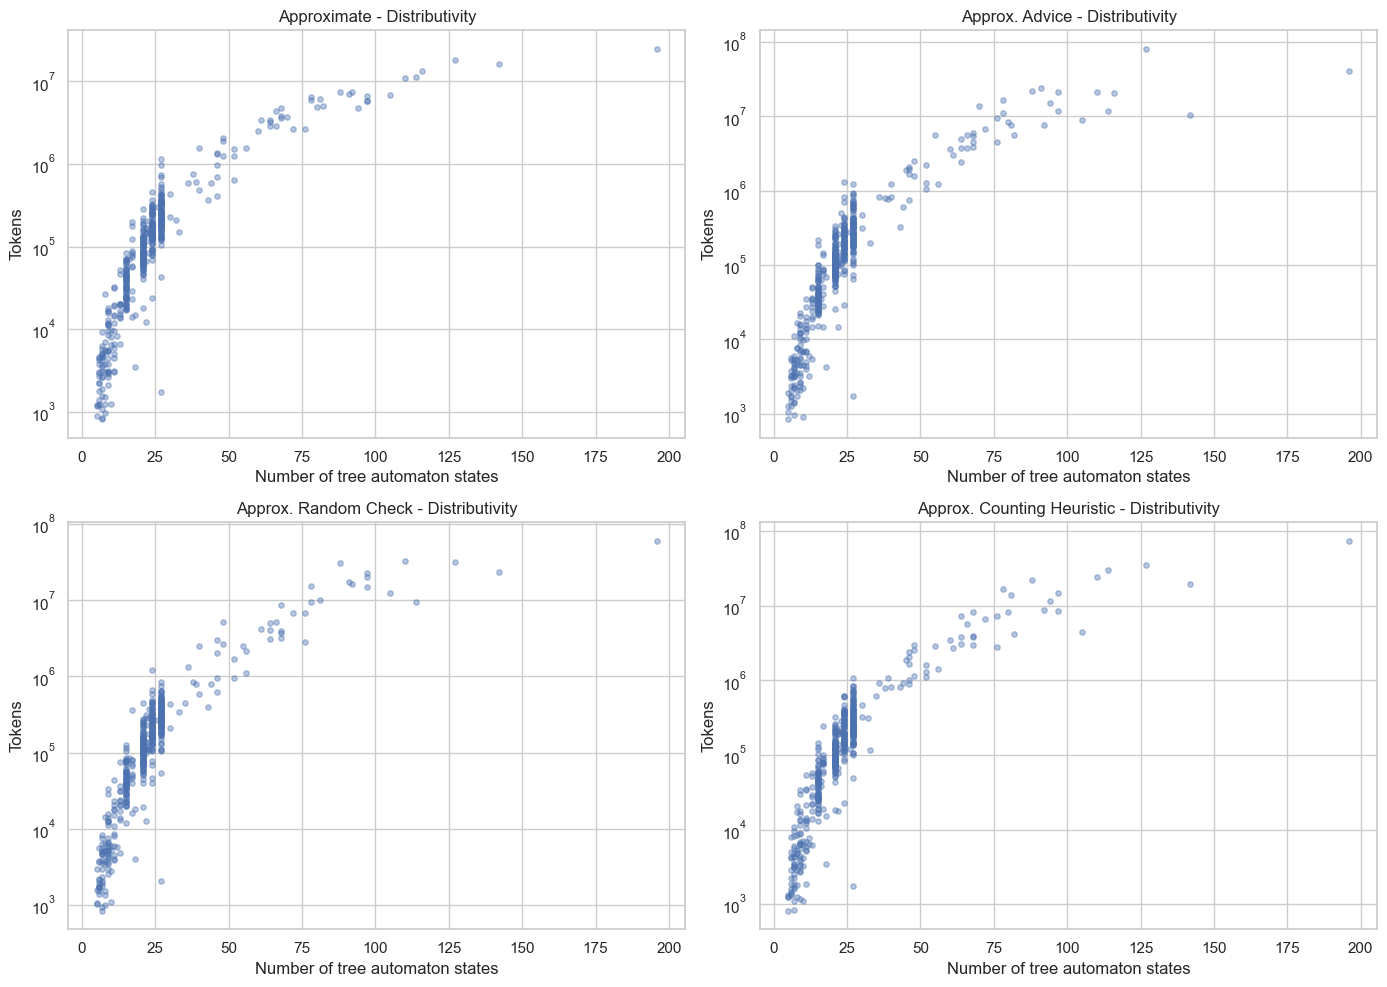

In [21]:
# Tokens vs number of states - Distributivity
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods_dist = [
    ('Approximate tokens', 'Approximate is_found', 'Approximate'),
    ('Approximate advice tokens', 'Approximate advice is_found', 'Approx. Advice'),
    ('Approximate random check tokens', 'Approximate random check is_found', 'Approx. Random Check'),
    ('Approximate counting heuristic tokens', 'Approximate counting heuristic is_found', 'Approx. Counting Heuristic')
]

for idx, (token_col, found_col, name) in enumerate(methods_dist):
    ax = axes[idx // 2][idx % 2]
    subset = dist_valid[dist_valid[found_col] == 1]
    ax.scatter(subset['States in tree automata'], subset[token_col], alpha=0.4, s=15)
    ax.set_xlabel('Number of tree automaton states')
    ax.set_ylabel('Tokens')
    ax.set_title(f'{name} - Distributivity')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **2×2 grid of scatter plots:** Each subplot shows the relationship between the number of tree automaton states (x-axis) and the number of consumed tokens (y-axis, log scale) for one of the four approximate methods on the Distributivity property. This reveals how token consumption scales with automaton complexity for each method. Points higher on the y-axis indicate experiments that required more tokens.


## 2.3 Profitability analysis - Distributivity

Analogous analysis as for Associativity: comparing the 4 approximate methods among themselves.


In [22]:
# Profitability analysis - Distributivity
# Filter: only experiments where ALL approximate methods found the automaton
dist_all_approx = dist_valid[
    (dist_valid['Approximate is_found'] == 1) &
    (dist_valid['Approximate advice is_found'] == 1) &
    (dist_valid['Approximate random check is_found'] == 1) &
    (dist_valid['Approximate counting heuristic is_found'] == 1)
].copy()

print(f"Experiments where all 4 approximate methods succeeded: {len(dist_all_approx)} / {len(dist_valid)}")

methods_approx_d = {
    'Approximate': ('Approximate tokens', 'Approximate time'),
    'Approx. Advice': ('Approximate advice tokens', 'Approximate advice time'),
    'Approx. Random': ('Approximate random check tokens', 'Approximate random check time'),
    'Approx. Counting': ('Approximate counting heuristic tokens', 'Approximate counting heuristic time'),
}

print(f"\n{'Method':<20} {'Mean tokens':<15} {'Median tokens':<15} {'Mean time [s]':<15}")
print("-" * 65)
for name, (tok_col, time_col) in methods_approx_d.items():
    print(f"{name:<20} {dist_all_approx[tok_col].mean():<15.0f} {dist_all_approx[tok_col].median():<15.0f} {dist_all_approx[time_col].mean():<15.2f}")

# Break-even cost per 1000 tokens where each method becomes cheaper than Approximate
print("\n--- Break-even cost per 1000 tokens: method becomes cheaper than Approximate (method 3) ---")
print(f"{'Comparison':<35} {'Mean token diff':<18} {'Mean time diff [ms]':<22} {'Mean break-even [ms/1k tokens]':<25}")
print("-" * 100)

baseline_tokens_d = dist_all_approx['Approximate tokens']
baseline_time_d = dist_all_approx['Approximate time']

for name, (tok_col, time_col) in methods_approx_d.items():
    if name == 'Approximate':
        continue
    method_tokens = dist_all_approx[tok_col]
    method_time = dist_all_approx[time_col]
    
    token_diff = (method_tokens - baseline_tokens_d) / 1000
    time_diff_ms = (baseline_time_d - method_time) * 1000  # convert s to ms
    
    mask = token_diff != 0
    breakeven = time_diff_ms[mask] / token_diff[mask]
    print(f"{name + ' vs Approximate':<35} {token_diff.mean():<18.0f} {time_diff_ms.mean():<22.0f} {breakeven.mean():<25.2e}")


Experiments where all 4 approximate methods succeeded: 399 / 567

Method               Mean tokens     Median tokens   Mean time [s]  
-----------------------------------------------------------------
Approximate          520101          86210           4.40           
Approx. Advice       890060          106661          4.47           
Approx. Random       935792          111456          4.50           
Approx. Counting     933970          103826          4.49           

--- Break-even cost per 1000 tokens: method becomes cheaper than Approximate (method 3) ---
Comparison                          Mean token diff    Mean time diff [ms]    Mean break-even [ms/1k tokens]
----------------------------------------------------------------------------------------------------
Approx. Advice vs Approximate       370                -68                    6.36e+02                 
Approx. Random vs Approximate       416                -98                    -2.24e+02                
Approx. Coun

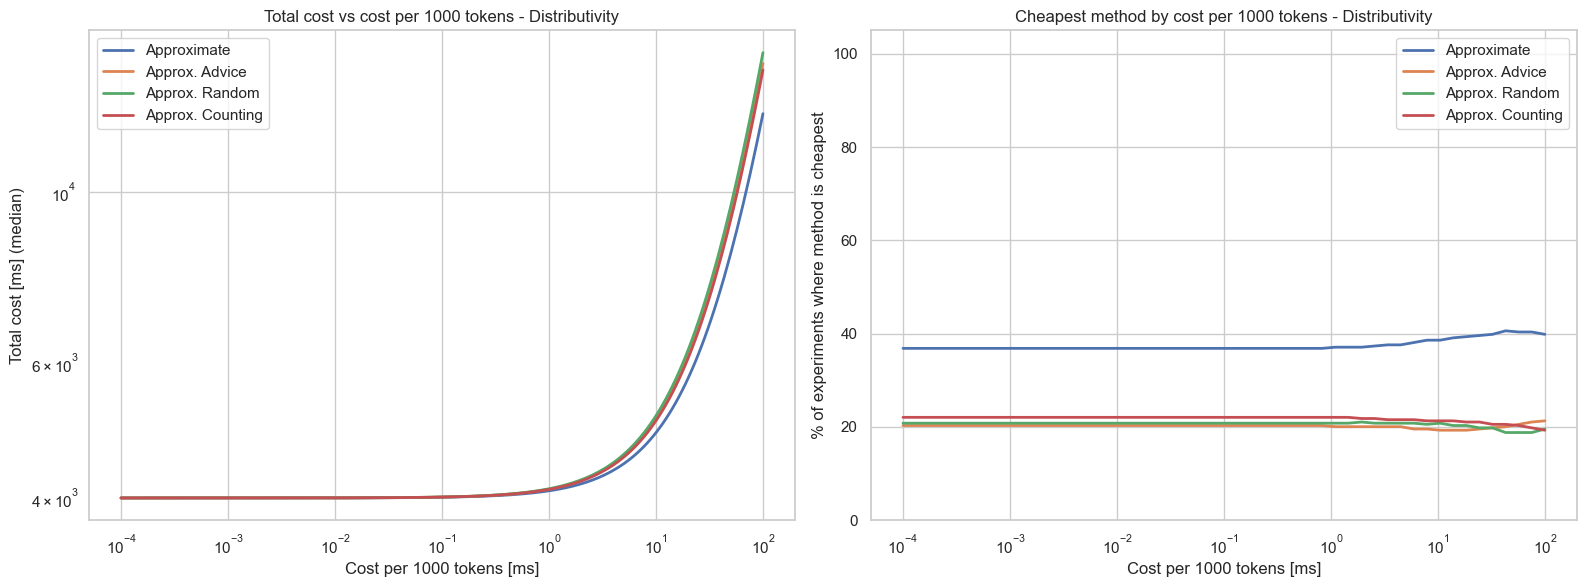

In [23]:
# Break-even chart - Distributivity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: total cost vs cost per 1000 tokens for each method
token_costs_range = np.logspace(-4, 2, 200)  # ms per 1000 tokens

for name, (tok_col, time_col) in methods_approx_d.items():
    median_tokens = dist_all_approx[tok_col].median()
    median_time_ms = dist_all_approx[time_col].median() * 1000  # s -> ms
    total_cost_ms = (median_tokens / 1000) * token_costs_range + median_time_ms
    axes[0].loglog(token_costs_range, total_cost_ms, label=name, linewidth=2)

axes[0].set_xlabel('Cost per 1000 tokens [ms]')
axes[0].set_ylabel('Total cost [ms] (median)')
axes[0].set_title('Total cost vs cost per 1000 tokens - Distributivity')
axes[0].legend()
axes[0].grid(True)

# Right plot: % of experiments where each method is the cheapest
token_costs_pct = np.logspace(-4, 2, 50)  # ms per 1000 tokens
pct_cheapest_d = {name: [] for name in methods_approx_d.keys()}

for tc in token_costs_pct:
    costs = {}
    for name, (tok_col, time_col) in methods_approx_d.items():
        costs[name] = (dist_all_approx[tok_col] / 1000) * tc + dist_all_approx[time_col] * 1000
    
    cost_df = pd.DataFrame(costs)
    cheapest = cost_df.idxmin(axis=1)
    for name in methods_approx_d.keys():
        pct_cheapest_d[name].append((cheapest == name).mean() * 100)

for name in methods_approx_d.keys():
    axes[1].semilogx(token_costs_pct, pct_cheapest_d[name], label=name, linewidth=2)

axes[1].set_xlabel('Cost per 1000 tokens [ms]')
axes[1].set_ylabel('% of experiments where method is cheapest')
axes[1].set_title('Cheapest method by cost per 1000 tokens - Distributivity')
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **Left (Total cost vs cost per 1000 tokens):** Shows how the total cost (time + token cost) changes as the price per 1000 tokens varies for the Distributivity property. Each line represents one approximate method. The crossover points indicate where one method becomes cheaper than another.
- **Right (Cheapest method percentage):** For each token cost value, shows the percentage of experiments where each method was the cheapest option for the Distributivity property. This reveals which method dominates at different price points.


## 2.4 Per-automaton break-even token cost - Distributivity

Same approach as for Associativity: compute break-even cost per 1000 tokens for each individual automaton, then aggregate.


In [24]:
# Per-automaton break-even token cost - Distributivity

comparisons_dist = {
    'Approx. Advice (4) vs Approx. (3)': {
        'baseline': ('Approximate tokens', 'Approximate time', 'Approximate is_found'),
        'method': ('Approximate advice tokens', 'Approximate advice time', 'Approximate advice is_found'),
    },
    'Approx. Random (5) vs Approx. (3)': {
        'baseline': ('Approximate tokens', 'Approximate time', 'Approximate is_found'),
        'method': ('Approximate random check tokens', 'Approximate random check time', 'Approximate random check is_found'),
    },
    'Approx. Counting (6) vs Approx. (3)': {
        'baseline': ('Approximate tokens', 'Approximate time', 'Approximate is_found'),
        'method': ('Approximate counting heuristic tokens', 'Approximate counting heuristic time', 'Approximate counting heuristic is_found'),
    },
}

print("=== Distributivity: Per-automaton break-even cost [ms / 1000 tokens] ===")
print(f"{'Comparison':<40} {'Count':<8} {'> 0':<8} {'Mean':<12} {'Median':<12} {'Min':<12} {'Max':<12} {'Std':<12}")
print("-" * 112)

breakeven_data_dist = {}

for comp_name, cols in comparisons_dist.items():
    b_tok, b_time, b_found = cols['baseline']
    m_tok, m_time, m_found = cols['method']
    
    # Filter: both methods found the automaton
    mask = (dist_valid[b_found] == 1) & (dist_valid[m_found] == 1)
    subset = dist_valid[mask].copy()
    
    # break-even: c = (time_method - time_baseline) * 1000 / ((tokens_baseline - tokens_method) / 1000)
    token_diff = (subset[b_tok] - subset[m_tok]) / 1000
    time_diff_ms = (subset[m_time] - subset[b_time]) * 1000
    
    valid = token_diff != 0
    breakeven_values = time_diff_ms[valid] / token_diff[valid]
    
    breakeven_data_dist[comp_name] = breakeven_values
    
    print(f"{comp_name:<40} {len(breakeven_values):<8} {(breakeven_values > 0).sum():<8} {breakeven_values.mean():<12.4f} {breakeven_values.median():<12.4f} {breakeven_values.min():<12.4f} {breakeven_values.max():<12.4f} {breakeven_values.std():<12.4f}")


=== Distributivity: Per-automaton break-even cost [ms / 1000 tokens] ===
Comparison                               Count    > 0      Mean         Median       Min          Max          Std         
----------------------------------------------------------------------------------------------------------------
Approx. Advice (4) vs Approx. (3)        470      42       534.1511     0.0000       -2024.2915   250000.0000  11536.8917  
Approx. Random (5) vs Approx. (3)        457      55       -196.5304    0.0000       -100000.0000 14705.8824   4794.2542   
Approx. Counting (6) vs Approx. (3)      472      46       -354.8072    0.0000       -111111.1111 7042.2535    5415.6125   


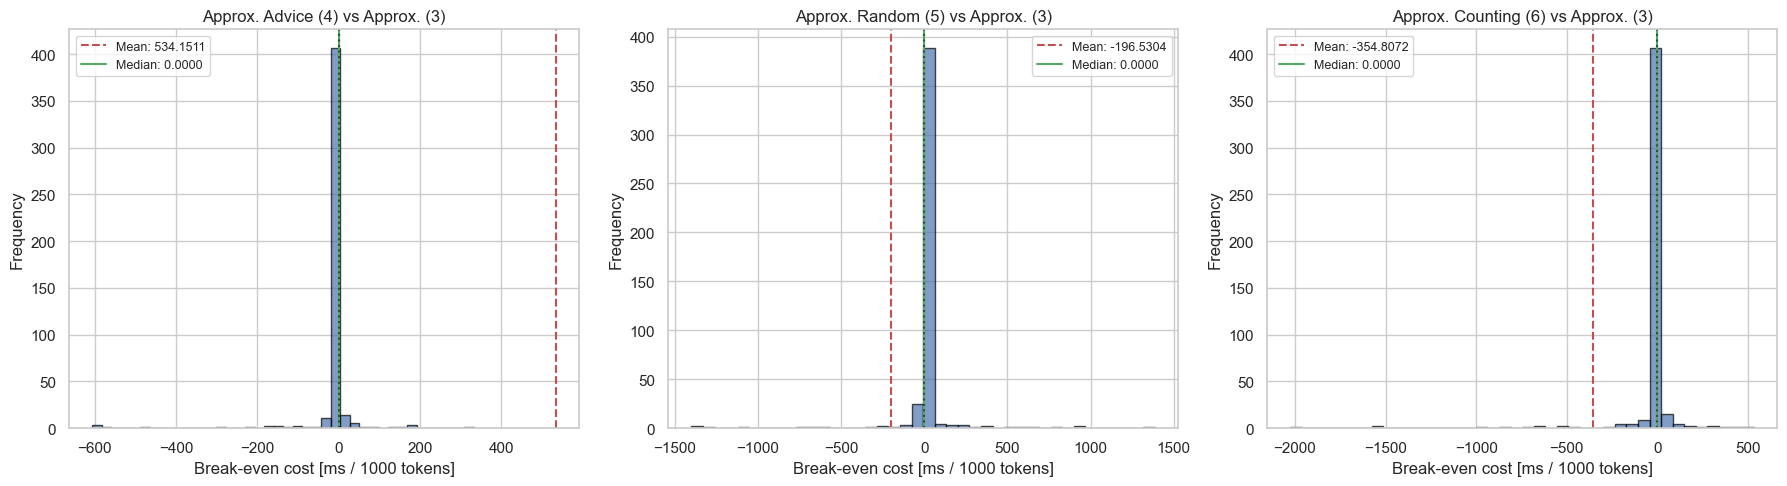

In [25]:
# Distribution of per-automaton break-even values - Distributivity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (comp_name, values) in enumerate(breakeven_data_dist.items()):
    ax = axes[idx]
    q01 = values.quantile(0.01)
    q99 = values.quantile(0.99)
    filtered = values[(values >= q01) & (values <= q99)]
    
    ax.hist(filtered, bins=40, edgecolor='black', alpha=0.7)
    ax.axvline(x=values.mean(), color='r', linestyle='--', label=f'Mean: {values.mean():.4f}')
    ax.axvline(x=values.median(), color='g', linestyle='-', label=f'Median: {values.median():.4f}')
    ax.axvline(x=0, color='black', linestyle=':', alpha=0.5)
    ax.set_xlabel('Break-even cost [ms / 1000 tokens]')
    ax.set_ylabel('Frequency')
    ax.set_title(comp_name)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **Three histograms:** Each histogram shows the distribution of per-automaton break-even token cost values for one comparison pair on the Distributivity property. The break-even value is the cost per 1000 tokens at which the compared method becomes cheaper than the baseline Approximate method. A vertical red line marks the median. Values to the left of the median indicate experiments where the alternative method becomes profitable at lower token costs.


---
# 3. Comparative Summary


## 3.1 Comparison of both experiments


In [26]:
# Comparative summary
print("=" * 80)
print("SUMMARY")
print("=" * 80)

print("\n--- Equivalence queries: Standard vs Advice ---")
print(f"{'Metric':<35} {'Associativity':<20} {'Distributivity':<20}")
print("-" * 75)

conn_red_mean = (1 - conn_valid['Advice equivalence queries'].mean() / conn_valid['Standard equivalence queries'].mean()) * 100
dist_red_mean = (1 - dist_valid['Advice equivalence queries'].mean() / dist_valid['Standard equivalence queries'].mean()) * 100
conn_red_med = (1 - conn_valid['Advice equivalence queries'].median() / conn_valid['Standard equivalence queries'].median()) * 100
dist_red_med = (1 - dist_valid['Advice equivalence queries'].median() / dist_valid['Standard equivalence queries'].median()) * 100

print(f"{'Eq. queries reduction (mean)':<35} {conn_red_mean:<20.1f}% {dist_red_mean:<20.1f}%")
print(f"{'Eq. queries reduction (median)':<35} {conn_red_med:<20.1f}% {dist_red_med:<20.1f}%")
print(f"{'Mean Standard eq. queries':<35} {conn_valid['Standard equivalence queries'].mean():<20.1f} {dist_valid['Standard equivalence queries'].mean():<20.1f}")
print(f"{'Mean Advice eq. queries':<35} {conn_valid['Advice equivalence queries'].mean():<20.1f} {dist_valid['Advice equivalence queries'].mean():<20.1f}")

print("\n--- Approximation methods: success rate (% of automata found) ---")
print(f"{'Method':<35} {'Associativity':<20} {'Distributivity':<20}")
print("-" * 75)
print(f"{'Approximate':<35} {100*len(conn_approx)/len(conn_valid):<20.1f}% {100*len(dist_approx)/len(dist_valid):<20.1f}%")
print(f"{'Approximate advice':<35} {100*len(conn_approx_adv)/len(conn_valid):<20.1f}% {100*len(dist_approx_adv)/len(dist_valid):<20.1f}%")
print(f"{'Approximate random check':<35} {100*len(conn_approx_rand)/len(conn_valid):<20.1f}% {100*len(dist_approx_rand)/len(dist_valid):<20.1f}%")
print(f"{'Approximate counting heuristic':<35} {100*len(conn_approx_count)/len(conn_valid):<20.1f}% {100*len(dist_approx_count)/len(dist_valid):<20.1f}%")

print("\n--- Approximation methods: median tokens (successful only) ---")
print(f"{'Method':<35} {'Associativity':<20} {'Distributivity':<20}")
print("-" * 75)
print(f"{'Approximate':<35} {conn_approx['Approximate tokens'].median():<20.0f} {dist_approx['Approximate tokens'].median():<20.0f}")
print(f"{'Approximate advice':<35} {conn_approx_adv['Approximate advice tokens'].median():<20.0f} {dist_approx_adv['Approximate advice tokens'].median():<20.0f}")
print(f"{'Approximate random check':<35} {conn_approx_rand['Approximate random check tokens'].median():<20.0f} {dist_approx_rand['Approximate random check tokens'].median():<20.0f}")
print(f"{'Approximate counting heuristic':<35} {conn_approx_count['Approximate counting heuristic tokens'].median():<20.0f} {dist_approx_count['Approximate counting heuristic tokens'].median():<20.0f}")


SUMMARY

--- Equivalence queries: Standard vs Advice ---
Metric                              Associativity        Distributivity      
---------------------------------------------------------------------------
Eq. queries reduction (mean)        78.5                % 64.0                %
Eq. queries reduction (median)      83.3                % 69.2                %
Mean Standard eq. queries           12.0                 13.5                
Mean Advice eq. queries             2.6                  4.8                 

--- Approximation methods: success rate (% of automata found) ---
Method                              Associativity        Distributivity      
---------------------------------------------------------------------------
Approximate                         91.3                % 90.3                %
Approximate advice                  96.7                % 91.2                %
Approximate random check            95.4                % 88.9                %
Approximate 

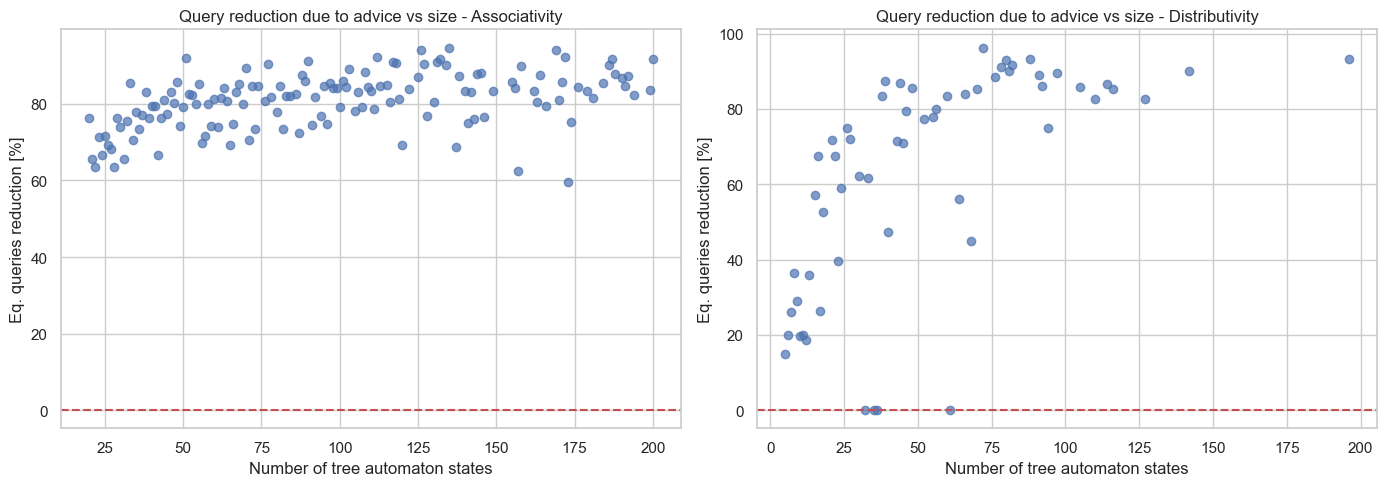

In [27]:
# Comparison of eq queries reduction vs automaton size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Associativity
conn_ratio_by_states = conn_valid[conn_valid['Standard equivalence queries'] > 0].copy()
conn_ratio_by_states['reduction'] = 1 - conn_ratio_by_states['Advice equivalence queries'] / conn_ratio_by_states['Standard equivalence queries']
conn_red_grouped = conn_ratio_by_states.groupby('States in tree automata')['reduction'].mean().reset_index()

axes[0].scatter(conn_red_grouped['States in tree automata'], conn_red_grouped['reduction'] * 100, alpha=0.7)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Number of tree automaton states')
axes[0].set_ylabel('Eq. queries reduction [%]')
axes[0].set_title('Query reduction due to advice vs size - Associativity')

# Distributivity
dist_ratio_by_states = dist_valid[dist_valid['Standard equivalence queries'] > 0].copy()
dist_ratio_by_states['reduction'] = 1 - dist_ratio_by_states['Advice equivalence queries'] / dist_ratio_by_states['Standard equivalence queries']
dist_red_grouped = dist_ratio_by_states.groupby('States in tree automata')['reduction'].mean().reset_index()

axes[1].scatter(dist_red_grouped['States in tree automata'], dist_red_grouped['reduction'] * 100, alpha=0.7)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Number of tree automaton states')
axes[1].set_ylabel('Eq. queries reduction [%]')
axes[1].set_title('Query reduction due to advice vs size - Distributivity')

plt.tight_layout()
plt.show()


**Chart descriptions:**

- **Left (Associativity):** Shows the relationship between automaton size (number of states) and the reduction in equivalence queries achieved by using advice, for the Associativity property. This reveals whether larger automata benefit more from the advice-guided approach.
- **Right (Distributivity):** Same analysis for the Distributivity property. Comparing both plots reveals whether the effectiveness of advice depends on the type of rewriting rule or the automaton size.


## 3.2 Key Results Summary

| # | Fact | Value |
|---|------|-------|
| 1 | Equivalence queries reduction (Associativity, mean) | **78.5%** |
| 2 | Equivalence queries reduction (Distributivity, mean) | **64.0%** |
| 3 | Mean equivalence queries: Standard vs Advice (Associativity) | 12.0 → 2.6 |
| 4 | Mean equivalence queries: Standard vs Advice (Distributivity) | 13.5 → 4.8 |
| 5 | Associativity mean token difference: Approx. Random - Approximate | 5037 |
| 6 | Token cost () in Distributivity needed to became Approx. Advice more effective than Approximate | 636ms / 1000 tokens|



## 3.3 Conclusions

### Equivalence queries (Standard vs Advice):
- Advice significantly reduces the number of equivalence queries in both experiments
- The reduction is particularly visible for larger automata

### Approximation methods:
- Methods with advice (Approximate advice, Random check, Counting heuristic) have a higher success rate than Approximate without advice
- The number of tokens grows with automaton size (exponentially)
- Methods with heuristics (random check, counting) can be more token-efficient
- Random check heuristic uses random tree with big height. Probably that's why it consumes huge number of tokens.

### Profitability:
- The maximum token cost at which approximation is profitable grows linearly with the equivalence query cost
- For typical eq_query costs (a few to tens of seconds), the token cost must be very low (on the order of microseconds) for approximation to be profitable
- Advice improves the profitability of approximation because it reduces the number of equivalence queries to be replaced


# Post Scriptum

There were decision made after previous experiments to test also small elimination rule.

## Elimination rule: f(g(X), g(Y)) -> X
There were only first two variants of learning algorithms ran.


In [3]:
elim_df = pd.read_csv('elimination_merged_results.csv')

print(f"Elimination: {len(elim_df)} rows")
print()
print("Elimination - columns:")
print(elim_df.columns.tolist())

Elimination: 79 rows

Elimination - columns:
['Number of leaf symbols', 'States in tree automata', 'Standard equivalence queries', 'Standard time', 'Advice equivalence queries', 'Advice time']


In [5]:
# Only valid experiments - remove extreme values using IQR method
elim_valid = elim_df.copy()

# Remove trivial cases (too few eq queries to be meaningful)
MIN_EQ_QUERIES = 3
elim_valid = elim_valid[elim_valid['Standard equivalence queries'] >= MIN_EQ_QUERIES]

# Remove outliers based on Standard equivalence queries (IQR method)
Q1 = elim_valid['Standard equivalence queries'].quantile(0.25)
Q3 = elim_valid['Standard equivalence queries'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Before filtering: {len(elim_df)} rows")
print(f"Removed trivial cases (Standard eq. queries < {MIN_EQ_QUERIES}): {len(elim_df) - len(elim_valid)} rows")
print(f"IQR bounds for Standard eq. queries: [{lower_bound:.1f}, {upper_bound:.1f}]")

elim_valid = elim_valid[
    (elim_valid['Standard equivalence queries'] >= lower_bound) &
    (elim_valid['Standard equivalence queries'] <= upper_bound)
]

print(f"After filtering: {len(elim_valid)} rows (removed {len(elim_df) - len(elim_valid)} total)")

print(f"\nExperiments count: {len(elim_valid)}")
print(f"\nEquivalence query statistics:")
print(f"  Standard - mean: {elim_valid['Standard equivalence queries'].mean():.2f}, median: {elim_valid['Standard equivalence queries'].median():.1f}")
print(f"  Advice   - mean: {elim_valid['Advice equivalence queries'].mean():.2f}, median: {elim_valid['Advice equivalence queries'].median():.1f}")
print(f"\n  Profit (mean): {(1 - elim_valid['Advice equivalence queries'].mean() / elim_valid['Standard equivalence queries'].mean()) * 100:.1f}%")
print(f"  Profit (median): {(1 - elim_valid['Advice equivalence queries'].median() / elim_valid['Standard equivalence queries'].median()) * 100:.1f}%")


Before filtering: 79 rows
Removed trivial cases (Standard eq. queries < 3): 0 rows
IQR bounds for Standard eq. queries: [6.0, 38.0]
After filtering: 77 rows (removed 2 total)

Experiments count: 77

Equivalence query statistics:
  Standard - mean: 22.16, median: 22.0
  Advice   - mean: 2.58, median: 2.0

  Profit (mean): 88.3%
  Profit (median): 90.9%
